# Visualisatie — Matplotlib

**Matplotlib** is de meest gebruikte Python-bibliotheek voor het aanmaken van grafieken. Het is de basis waarop Seaborn en Pandas hun visualisaties bouwen.

In deze notebook leer je:
- De anatomie van een Matplotlib-figuur (`Figure` en `Axes`)
- De meest gebruikte grafieksoorten: lijn, scatter, histogram, bar
- Subplots aanmaken voor meerdere grafieken naast/onder elkaar
- Aanpassen: titels, aslabels, legenda, kleuren

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 100

## Anatomie van een figuur

In Matplotlib is een **Figure** de buitenste container (het witte vel papier). Daarbinnen zitten één of meer **Axes**-objecten — de eigenlijke grafiek met assen, titels en data.

De aanbevolen werkwijze is de **object-georiënteerde API**: je werkt expliciet met `fig` en `ax`.

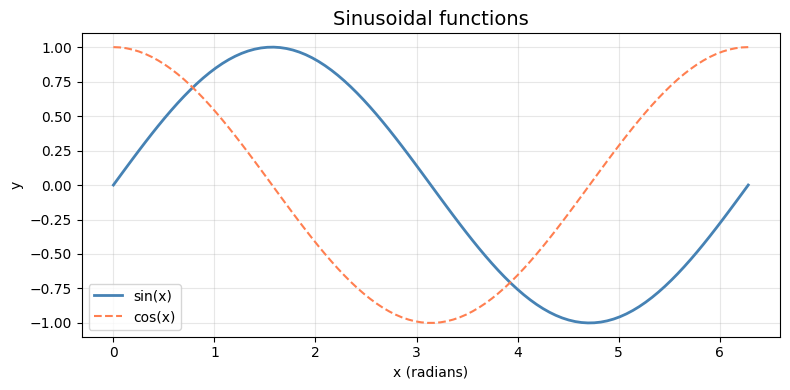

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.linspace(0, 2 * np.pi, 100)
ax.plot(x, np.sin(x), label="sin(x)", color="steelblue", linewidth=2)
ax.plot(x, np.cos(x), label="cos(x)", color="coral", linestyle="--")

ax.set_title("Sinusoidal functions", fontsize=14)
ax.set_xlabel("x (radians)")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Lijnplot

Lijnplots zijn geschikt voor het visualiseren van **trends** — bijv. tijdreeksen.

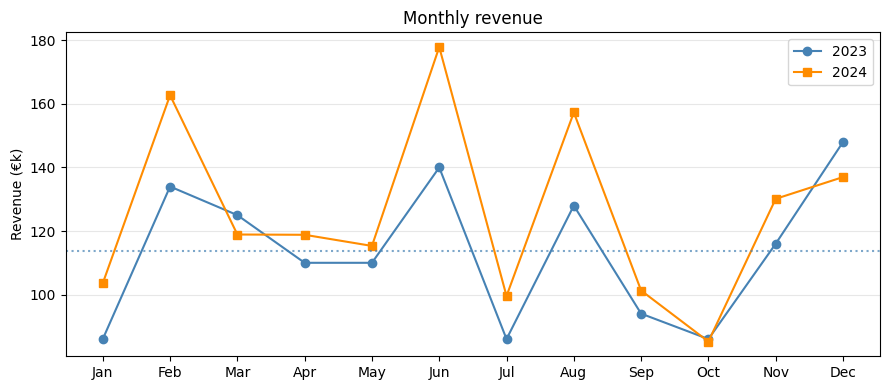

In [3]:
rng = np.random.default_rng(42)
months = list(range(1, 13))
revenue_2023 = rng.integers(80, 150, size=12).astype(float)
revenue_2024 = revenue_2023 * rng.uniform(0.9, 1.3, size=12)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(months, revenue_2023, marker="o", label="2023", color="steelblue")
ax.plot(months, revenue_2024, marker="s", label="2024", color="darkorange")
ax.axhline(y=revenue_2023.mean(), color="steelblue", linestyle=":", alpha=0.7)

ax.set_xticks(months)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_title("Monthly revenue")
ax.set_ylabel("Revenue (€k)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter plot

Scatter plots tonen de **relatie** tussen twee numerieke variabelen. Kleur en grootte kunnen een derde variabele coderen.

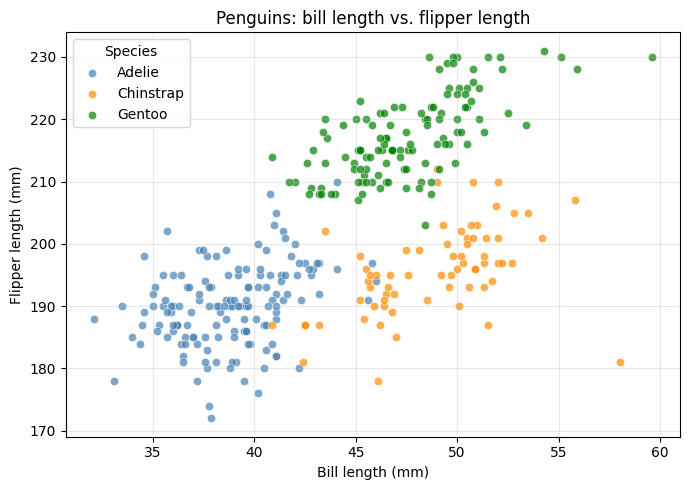

In [4]:
penguins = sns.load_dataset("penguins").dropna()

# Color per species
colors = {"Adelie": "steelblue", "Chinstrap": "darkorange", "Gentoo": "green"}

fig, ax = plt.subplots(figsize=(7, 5))

for species, group in penguins.groupby("species"):
    ax.scatter(
        group["bill_length_mm"],
        group["flipper_length_mm"],
        label=species,
        color=colors[species],
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
    )

ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Flipper length (mm)")
ax.set_title("Penguins: bill length vs. flipper length")
ax.legend(title="Species")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Histogram

Histogrammen tonen de **verdeling** van één numerieke variabele.

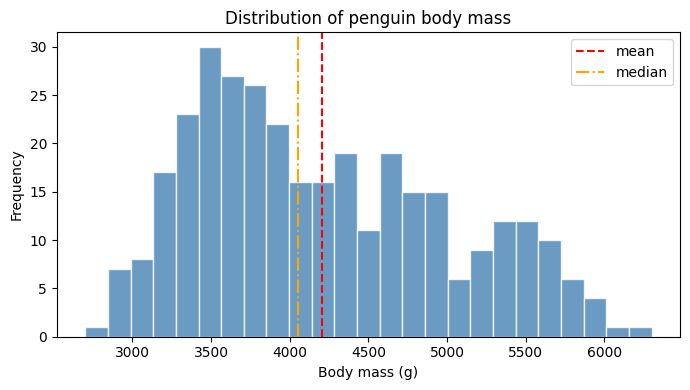

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(penguins["body_mass_g"], bins=25, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(penguins["body_mass_g"].mean(), color="red", linestyle="--", label="mean")
ax.axvline(penguins["body_mass_g"].median(), color="orange", linestyle="-.", label="median")

ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of penguin body mass")
ax.legend()

plt.tight_layout()
plt.show()

## Staafdiagram (bar chart)

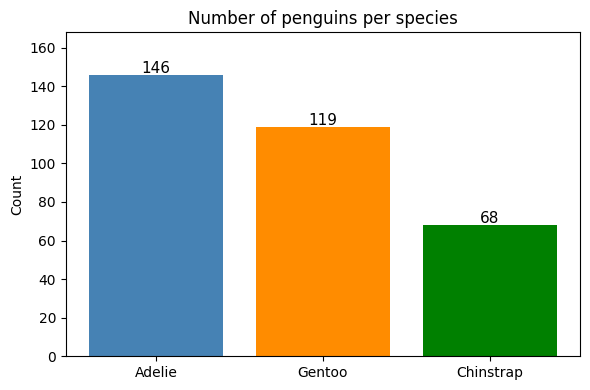

In [6]:
counts = penguins["species"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(counts.index, counts.values, color=["steelblue", "darkorange", "green"])

# Add count labels above each bar
for bar, value in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(value),
        ha="center",
        fontsize=11,
    )

ax.set_title("Number of penguins per species")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

## Subplots

Met `plt.subplots(nrows, ncols)` maak je een raster van meerdere grafieken in één figuur.

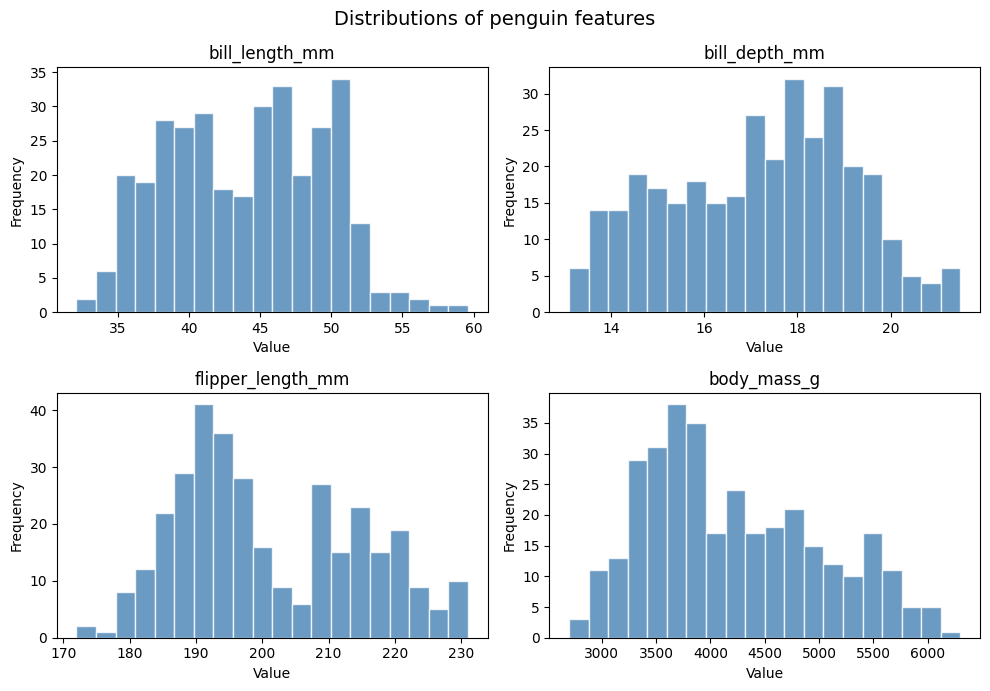

In [7]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()  # 2×2 grid → 1D array for easy iteration

for ax, column in zip(axes, numeric_cols):
    ax.hist(penguins[column].dropna(), bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

fig.suptitle("Distributions of penguin features", fontsize=14)
plt.tight_layout()
plt.show()

---

## Oefeningen

**Oefening 1** — Laad de Titanic-dataset (`sns.load_dataset("titanic")`). Maak een staafdiagram van het aantal overlevers per klasse (`pclass`). Gebruik kleur om te onderscheiden of ze overleefden (groen) of niet (rood). Voeg een legenda en aslabels toe.

In [8]:
titanic = sns.load_dataset("titanic")
# your solution here

**Oefening 2** — Maak een subplot-raster (1 rij, 2 kolommen) voor de Penguins-dataset:
- Links: histogram van `bill_length_mm`, met gemiddelde als verticale lijn
- Rechts: histogram van `body_mass_g`, met mediaan als verticale lijn

Zorg voor titels, aslabels en een legenda.

In [9]:
# your solution here

**Oefening 3** — Maak een scatter plot van `flipper_length_mm` (x) vs. `body_mass_g` (y) voor de Penguins-dataset. Kleur de punten per `island` (drie eilanden). Voeg gridlijnen, aslabels, een titel en een legenda toe.

In [10]:
# your solution here

**Oefening 4** — Sla één van je grafieken op als PNG-bestand met `fig.savefig("my_chart.png", dpi=150, bbox_inches="tight")`.

In [11]:
# your solution here